# Particle-spray Stream Modeling with streamspraydf

The particle-spray technique generates tidal streams by "spraying" particles
from the Lagrange points of a progenitor cluster as it orbits in a gravitational
potential. Each particle is given a small velocity kick and then integrated forward
in the potential. galpy provides two implementations (described in 
[Qian et al. 2022](https://ui.adsabs.harvard.edu/abs/2022MNRAS.511.2339Q/abstract)):

- `chen24spraydf`: the spray model from [Chen et al. (2024)](https://ui.adsabs.harvard.edu/abs/2025ApJS..276...32C/abstract)
- `fardal15spraydf`: the spray model from [Fardal et al. (2015)](https://ui.adsabs.harvard.edu/abs/2015MNRAS.452..301F/abstract)

These are faster to set up than `streamdf` and work in any potential.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from astropy import units as u
from galpy.df import chen24spraydf, fardal15spraydf
from galpy.potential import LogarithmicHaloPotential
from galpy.orbit import Orbit
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Setup

We set up a potential and a progenitor orbit. The particle-spray classes
only need the potential and the progenitor orbit (no action-angle machinery).

In [2]:
lp = LogarithmicHaloPotential(normalize=1.0, q=0.9)
prog = Orbit([1.56148083, 0.35081535, -1.97302, 0.33446162, -0.16101384, -0.7166])

## Initialize chen24spraydf

We create a spray model for the leading tail. The key parameters are:

- `progenitor_mass`: mass of the progenitor in solar masses
- `progenitor`: the progenitor orbit
- `pot`: the gravitational potential
- `tdisrupt`: time since disruption began (in Gyr when using physical units)
- `tail`: which tail to model (`'leading'`, `'trailing'`, or `'both'`)

In [3]:
spdf_lead = chen24spraydf(
    progenitor_mass=10**4.0 * u.Msun,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5 * u.Gyr,
    tail="leading",
)

## Sample stream particles

The `sample` method generates stream particles by spraying `n` particles
from the progenitor's Lagrange points and integrating them forward.

In [4]:
lead_stream = spdf_lead.sample(n=500)

Let's visualize the sampled stream particles:

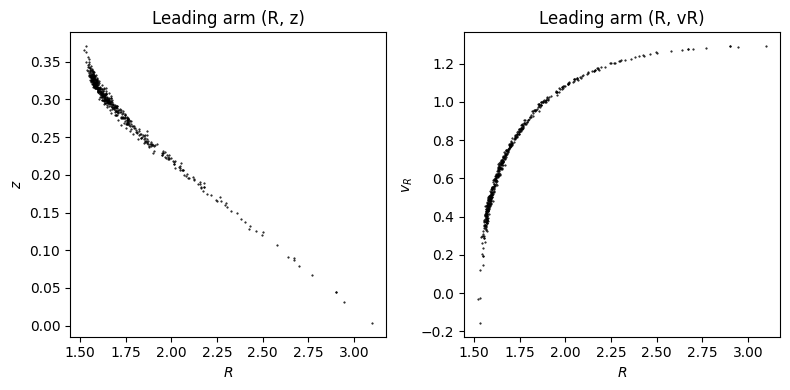

In [5]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(lead_stream.R(), lead_stream.z(), "k.", ms=1)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Leading arm (R, z)")
plt.subplot(1, 2, 2)
plt.plot(lead_stream.R(), lead_stream.vR(), "k.", ms=1)
plt.xlabel(r"$R$")
plt.ylabel(r"$v_R$")
plt.title("Leading arm (R, vR)")
plt.tight_layout();

## Leading and trailing arms with tail='both'

Using `tail='both'` generates both arms in one call. This is more
efficient than creating separate leading and trailing instances.

In [6]:
spdf_both = chen24spraydf(
    progenitor_mass=10**4.0 * u.Msun,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5 * u.Gyr,
    tail="both",
)
both_stream = spdf_both.sample(n=1000)

Plotting both arms in Cartesian coordinates:

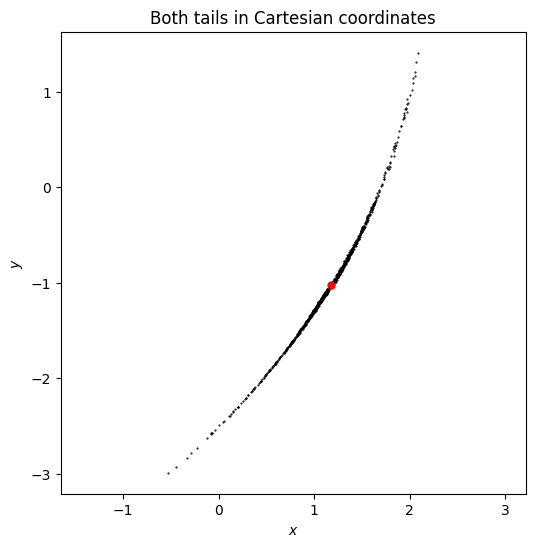

In [7]:
plt.figure(figsize=(6, 6))
plt.plot(both_stream.x(), both_stream.y(), "k.", ms=1)
plt.plot(prog.x(), prog.y(), "ro", ms=5)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Both tails in Cartesian coordinates")
plt.axis("equal");

## Using fardal15spraydf

`fardal15spraydf` provides an alternative spray model based on
Fardal et al. (2015). The interface is the same.

In [8]:
spdf_fardal = fardal15spraydf(
    progenitor_mass=10**4.0 * u.Msun,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5 * u.Gyr,
    tail="both",
)
fardal_stream = spdf_fardal.sample(n=1000)

Comparing the two spray models side by side:

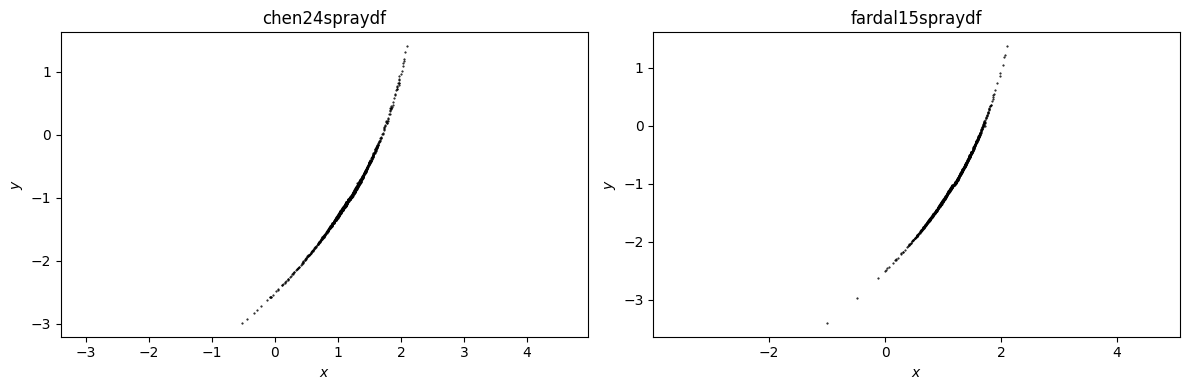

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(both_stream.x(), both_stream.y(), "k.", ms=1)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("chen24spraydf")
plt.axis("equal")
plt.subplot(1, 2, 2)
plt.plot(fardal_stream.x(), fardal_stream.y(), "k.", ms=1)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("fardal15spraydf")
plt.axis("equal")
plt.tight_layout();

## Progenitor self-gravity with progpot

The `streamspraydf` models can include the progenitor's gravity using the
`progpot` parameter:

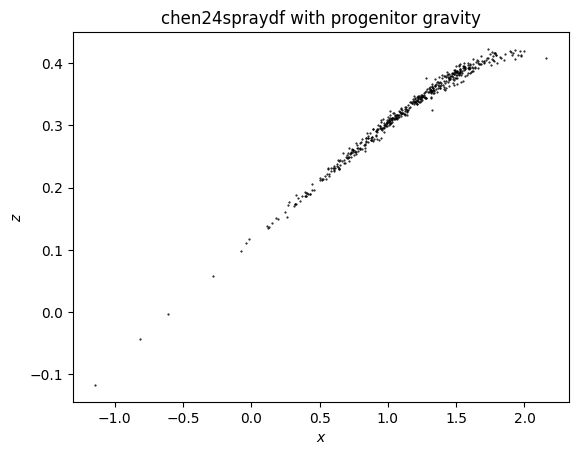

In [10]:
from galpy.potential import PlummerPotential

progpot = PlummerPotential(2 * 10.0**4.0 * u.Msun, 4.0 * u.pc)
spdf_with_prog = chen24spraydf(
    progenitor_mass=2 * 10.0**4.0 * u.Msun,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5 * u.Gyr,
    tail="both",
    progpot=progpot,
)
stream_with_prog = spdf_with_prog.sample(n=500)
plt.plot(stream_with_prog.x(), stream_with_prog.z(), "k.", ms=1)
plt.xlabel(r"$x$")
plt.ylabel(r"$z$")
plt.title("chen24spraydf with progenitor gravity");

## Integrating sampled orbits

The `sample` method can return integrated orbits (to the present time) using
`integrate=True`. You can also get the stripping times with `returndt=True`.
The returned `Orbit` object can be further integrated or analyzed:

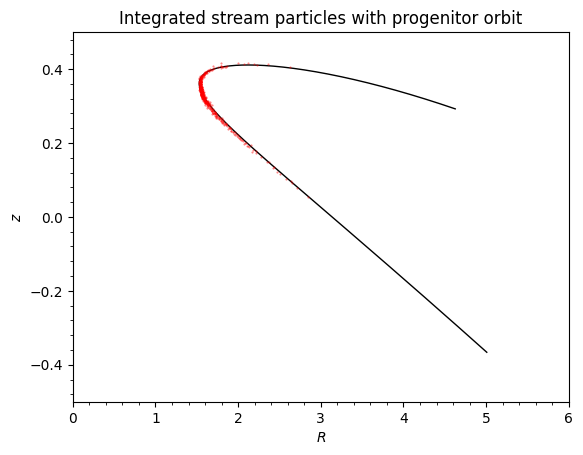

In [11]:
# Sample with integration and stripping times
orbs_integrated, dt = spdf_both.sample(n=500, returndt=True, integrate=True)

# Integrate the progenitor for context
ts_prog = numpy.linspace(0.0, 3.0, 301)
prog.integrate(ts_prog, lp)
prog.integrate(-ts_prog, lp)

# Plot the integrated stream with progenitor orbit
prog.plot(d1="R", d2="z", color="k", lw=1, xrange=[0.0, 6.0], yrange=[-0.5, 0.5])
plt.plot(orbs_integrated.R(), orbs_integrated.z(), "r.", ms=1, alpha=0.5)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Integrated stream particles with progenitor orbit");

You can also obtain the stream points at the time of stripping by using `integrate=False`:

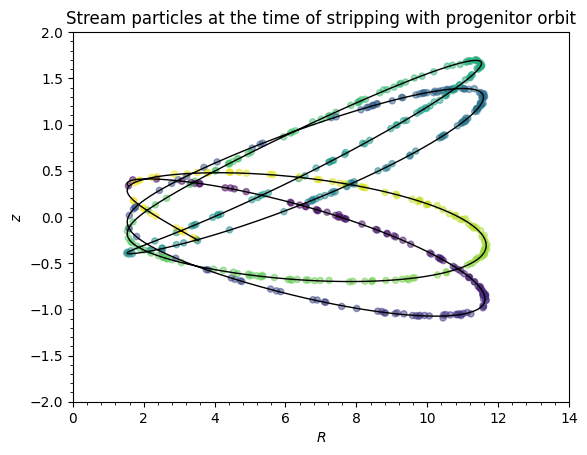

In [12]:
# Sample with integration and stripping times
orbs_not_integrated, dt = spdf_both.sample(n=500, returndt=True, integrate=False)

# Integrate the progenitor backwards for context
ts_prog = numpy.linspace(0.0, -4.5, 3001) * u.Gyr
prog.integrate(ts_prog, lp)

# Plot the integrated stream with progenitor orbit
prog.plot(d1="R", d2="z", color="k", lw=1, xrange=[0.0, 14.0], yrange=[-2.0, 2.0])
plt.scatter(
    orbs_not_integrated.R(), orbs_not_integrated.z(), c=dt, marker="o", s=20, alpha=0.5
)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Stream particles at the time of stripping with progenitor orbit");

## Different potential inputs

When initializing a particle-spray DF, you can also specify a different potential for computing the tidal radius and velocity distribution of the tidal debris, which can be useful when the overall potential contains pieces that are irrelevant for computing the tidal radius and that don’t allow the tidal radius to be computed (using the ``rtpot=`` option). If you want to generate a stream around a moving object, for example, a stream created within a satellite galaxy of the Milky Way, you can specify an orbit for the center of the satellite (``center=``) and the stream will be generated around this center rather than around the center of the total potential (this was used in [Qian et al. 2022](https://ui.adsabs.harvard.edu/abs/2022MNRAS.511.2339Q/abstract)); the center orbit is integrated in ``centerpot``, which can also differ from the potential that stream stars are integrated in (e.g., the stream stars may feel the potential from the satellite itself and/or the satellite could be experiencing dynamical friction which the stream stars do not feel).